In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import pypsa
from pathlib import Path

/home/lukas/micromamba/envs/pypsa-eur/lib/python3.12/site-packages/google/cloud/storage/__init__.py:35: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution
ERROR 1: PROJ: proj_create_from_database: Open of /home/lukas/micromamba/envs/pypsa-eur/share/proj failed


In [2]:
regions = gpd.read_file(
    Path.cwd().parent / 'resources' / 'regions_onshore_base_s_50.geojson'
).set_index('name')

/home/lukas/micromamba/envs/pypsa-eur/lib/python3.12/site-packages/pyogrio/__init__.py:7: DeprecationWarning: The 'shapely.geos' module is deprecated, and will be removed in a future version. All attributes of 'shapely.geos' are available directly from the top-level 'shapely' namespace (since shapely 2.0.0).
  import shapely.geos  # noqa: F401


In [12]:
n = pypsa.Network(
    Path.cwd().parent / 'results' / 'networks' / 'base_s_50__168H-T-H-B-I-A-dist1_2030_NT+very_slow_3000.nc'
)

INFO:pypsa.io:Imported network base_s_50__168H-T-H-B-I-A-dist1_2030_NT+very_slow_3000.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


In [41]:
ltype = [
    'heat<100 industry',
    'heat100-200 industry',
    'heat200-500 industry',
    'heat>500 industry',
    'gas for industry',
]

In [42]:
6 + 365 * 24

8766

In [43]:
loads = list()

for l in ltype:
    ss = n.loads.loc[n.loads.carrier == l, 'p_set'] * 8760
    ss = ss.groupby(ss.index.str[:2]).sum().mul(1e-6).rename(l)
    loads.append(ss)

loads = pd.concat(loads, axis=1)

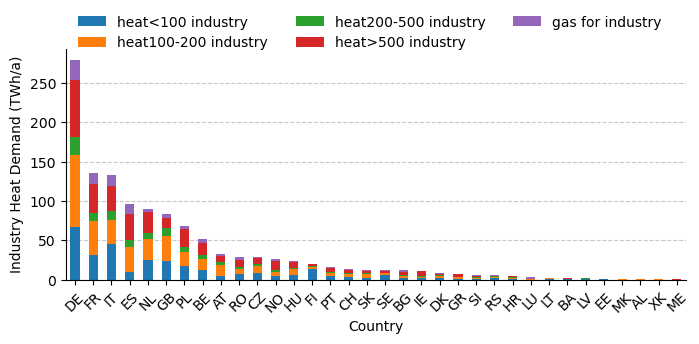

In [44]:
# Sort by total
loads_sorted = loads.loc[loads.sum(axis=1).sort_values(ascending=False).index]

# Create stacked bar plot
fig, ax = plt.subplots(figsize=(8, 3))
loads_sorted.plot(kind='bar', stacked=True, ax=ax)

# Customize plot
ax.set_xlabel('Country')
ax.set_ylabel('Industry Heat Demand (TWh/a)')
# ax.set_title('Industrial Heating Demand by Temperature Range')
ax.legend(bbox_to_anchor=(.0, 1.2), loc='upper left', ncol=3, frameon=False)
plt.xticks(rotation=45, ha='center')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

# plt.tight_layout()
plt.show()


In [61]:
n.links.loc[n.links.carrier == 'biogas to gas', ['bus0', 'bus1', 'bus2', 'efficiency', 'efficiency2', 'efficiency3', 'p_nom', 'p_nom_min', 'capital_cost', 'marginal_cost', 'p_nom_extendable']].head()

,bus0,bus1,bus2,efficiency,efficiency2,efficiency3,p_nom,p_nom_min,capital_cost,marginal_cost,p_nom_extendable
Link,,,,,,,,,,,
AL0 0 biogas to gas,AL0 0 biogas,AL0 0 gas,co2 atmosphere,1.0,-0.198,1.0,0.0,0.0,209515.793217,3.680417,True
AT0 0 biogas to gas,AT0 0 biogas,AT0 0 gas,co2 atmosphere,1.0,-0.198,1.0,0.0,0.0,209515.793217,3.680589,True
BA0 0 biogas to gas,BA0 0 biogas,BA0 0 gas,co2 atmosphere,1.0,-0.198,1.0,0.0,0.0,209515.793217,3.679434,True
BE0 0 biogas to gas,BE0 0 biogas,BE0 0 gas,co2 atmosphere,1.0,-0.198,1.0,0.0,0.0,209515.793217,3.680441,True
BG0 0 biogas to gas,BG0 0 biogas,BG0 0 gas,co2 atmosphere,1.0,-0.198,1.0,0.0,0.0,209515.793217,3.679879,True


In [60]:
n.links.loc[n.links.carrier == 'biogas to gas', ['p_nom', 'p_nom_min', ]].sum()

p_nom        0.0
p_nom_min    0.0
dtype: float64

In [ ]:
n.

In [52]:
# Find all links connected to biogas buses
biogas_buses = n.buses[n.buses.carrier == 'biogas'].index
biogas_links = n.links[(n.links.bus0.isin(biogas_buses)) | (n.links.bus1.isin(biogas_buses)) | (n.links.bus2.isin(biogas_buses))]
biogas_links.carrier.unique()

array(['biogas to gas'], dtype=object)

In [57]:
n.generators.loc[n.generators.carrier == 'biogas', ['p_nom', 'p_nom_min', 'capital_cost', 'marginal_cost', 'p_nom_extendable']].head()

,p_nom,p_nom_min,capital_cost,marginal_cost,p_nom_extendable
Generator,,,,,
AL0 0 biogas,1.678401e+05,0.0,0.0,62.445474,False
AT0 0 biogas,7.456363e+05,0.0,0.0,62.444358,False
BA0 0 biogas,1.539784e+05,0.0,0.0,62.445314,False
BE0 0 biogas,4.595291e+06,0.0,0.0,62.444971,False
BG0 0 biogas,5.590960e+05,0.0,0.0,62.444793,False


In [67]:
n.generators.loc[n.generators.carrier == 'biogas', ['p_nom']].sum() * 8760 / 1e6

p_nom    1.004107e+06
dtype: float64